# **AI Advanced Ahmed Yousrey Course Practice**

---
# **DAY 2 — Used Car Fair Price Engine (v2: Outlier Removal + Scaling)**
---

## STEP 1 — Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

---
## STEP 2 — Load Data
---

In [2]:
df = pd.read_csv('/content/used_cars.csv')
print(df.shape)
df.head()

(4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


---
## STEP 3 — Clean Target (price) & Remove Outlier Rows
---

=== Price Stats BEFORE outlier removal ===
count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

Prices above $200k: 75
Prices above $500k: 8


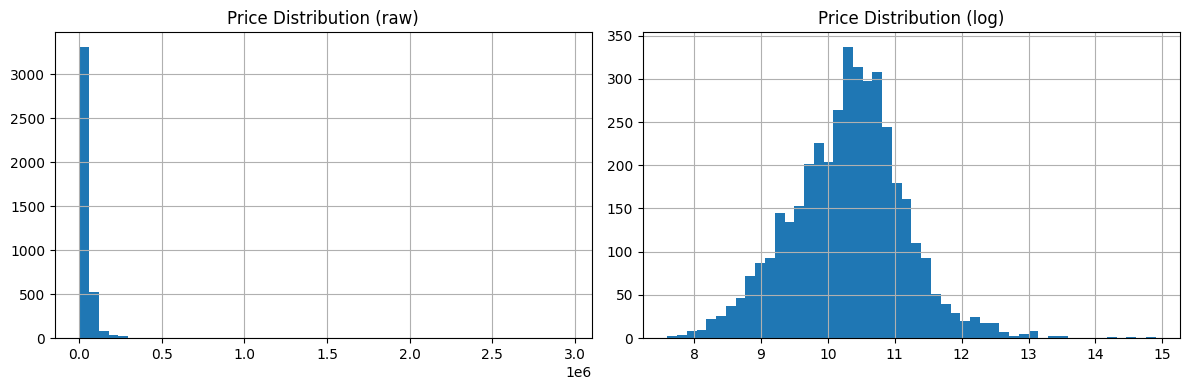

In [3]:
# Clean price column first
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Check the distribution BEFORE removing outliers
print('=== Price Stats BEFORE outlier removal ===')
print(df['price'].describe())
print(f'\nPrices above $200k: {(df["price"] > 200000).sum()}')
print(f'Prices above $500k: {(df["price"] > 500000).sum()}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['price'].hist(bins=50)
plt.title('Price Distribution (raw)')
plt.subplot(1, 2, 2)
np.log1p(df['price']).hist(bins=50)
plt.title('Price Distribution (log)')
plt.tight_layout()
plt.show()

In [4]:
# Remove outlier ROWS based on target price using IQR
# This is done on the full df BEFORE the split
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f'Lower bound: {lower_bound:,.0f}')
print(f'Upper bound: {upper_bound:,.0f}')

rows_before = len(df)
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
rows_after = len(df)

print(f'\nRows removed: {rows_before - rows_after}')
print(f'Rows remaining: {rows_after}')

print('\n=== Price Stats AFTER outlier removal ===')
print(df['price'].describe())

Lower bound: -31,985
Upper bound: 99,175

Rows removed: 244
Rows remaining: 3765

=== Price Stats AFTER outlier removal ===
count     3765.000000
mean     33518.196547
std      21369.125682
min       2000.000000
25%      16500.000000
50%      29600.000000
75%      45500.000000
max      99000.000000
Name: price, dtype: float64


---
## STEP 4 — Train / Test Split
---

In [5]:
X = df.drop('price', axis=1)
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('x_train:', x_train.shape)
print('x_test: ', x_test.shape)

x_train: (3012, 11)
x_test:  (753, 11)


---
## STEP 5 — Preprocessing
---

In [6]:
# --- fuel_type ---
x_train['fuel_type'] = x_train['fuel_type'].replace('\u2013', np.nan)
x_test['fuel_type']  = x_test['fuel_type'].replace('\u2013', np.nan)
fuel_mode = x_train['fuel_type'].mode()[0]
x_train['fuel_type'] = x_train['fuel_type'].fillna(fuel_mode)
x_test['fuel_type']  = x_test['fuel_type'].fillna(fuel_mode)

# --- accident ---
accident_mode = x_train['accident'].mode()[0]
x_train['accident'] = x_train['accident'].fillna(accident_mode)
x_test['accident']  = x_test['accident'].fillna(accident_mode)

# --- clean_title ---
x_train['clean_title'] = x_train['clean_title'].fillna('No')
x_test['clean_title']  = x_test['clean_title'].fillna('No')

print('Nulls remaining:', x_train.isna().sum().sum())

Nulls remaining: 0


In [7]:
# --- Extract from engine column ---
for data in [x_train, x_test]:
    data['horsepower'] = (
        data['engine'].str.extract(r'(\d+(?:\.\d+)?)HP')[0]
        .pipe(pd.to_numeric, errors='coerce')
    )
    data['engine_size'] = (
        data['engine'].str.extract(r'(\d+(?:\.\d+)?)L')[0]
        .pipe(pd.to_numeric, errors='coerce')
    )
    data['cylinders'] = (
        data['engine'].str.extract(r'(?:V|I)(\d+)|(\d+)\s*Cylinder')
        .bfill(axis=1).iloc[:, 0]
        .pipe(pd.to_numeric, errors='coerce')
    )
    data.drop('engine', axis=1, inplace=True)

for col in ['horsepower', 'engine_size', 'cylinders']:
    median_val = x_train[col].median()
    x_train[col] = x_train[col].fillna(median_val)
    x_test[col]  = x_test[col].fillna(median_val)

In [8]:
# --- Clean milage ---
for data in [x_train, x_test]:
    data['milage'] = (
        data['milage']
        .str.replace(',', '', regex=False)
        .str.replace(' mi.', '', regex=False)
        .astype(float)
    )

In [9]:
# --- Binary encode accident & clean_title ---
x_train['accident'] = x_train['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})
x_test['accident'] = x_test['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})

x_train['clean_title'] = x_train['clean_title'].map({'Yes': 1, 'No': 0})
x_test['clean_title']  = x_test['clean_title'].map({'Yes': 1, 'No': 0})

In [10]:
# --- car_age feature ---
x_train['car_age'] = 2025 - x_train['model_year']
x_test['car_age']  = 2025 - x_test['model_year']

In [11]:
# --- Frequency encoding for high-cardinality columns ---
freq_cols = ['brand', 'model', 'ext_col', 'int_col']

for col in freq_cols:
    freq_map = x_train[col].value_counts(normalize=True)
    x_train[col + '_freq'] = x_train[col].map(freq_map)
    x_test[col + '_freq']  = x_test[col].map(freq_map).fillna(0)

x_train = x_train.drop(columns=freq_cols)
x_test  = x_test.drop(columns=freq_cols)

In [12]:
# --- One-hot encoding for low-cardinality columns ---
onehot_cols = ['transmission', 'fuel_type']

x_train = pd.get_dummies(x_train, columns=onehot_cols, dtype=int)
x_test  = pd.get_dummies(x_test,  columns=onehot_cols, dtype=int)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

print('Final shape — train:', x_train.shape)
print('Final shape — test: ', x_test.shape)

Final shape — train: (3012, 69)
Final shape — test:  (753, 69)


---
## STEP 6 — Scaling

**Important note:** Scaling only affects Linear Regression, Ridge, and Lasso.
Random Forest and Gradient Boosting are tree-based — scaling has zero effect on them.
We scale anyway to give linear models a fair shot.

---

In [13]:
# Identify numeric columns to scale
# Do NOT scale binary columns (accident, clean_title, one-hot columns)
cols_to_scale = [
    'model_year', 'milage', 'horsepower', 'engine_size',
    'cylinders', 'car_age', 'brand_freq', 'model_freq',
    'ext_col_freq', 'int_col_freq'
]

scaler = StandardScaler()

# Fit ONLY on train, transform both
x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()

x_train_scaled[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test_scaled[cols_to_scale]  = scaler.transform(x_test[cols_to_scale])

print('Scaling done.')
print(x_train_scaled[cols_to_scale].describe().round(2))

Scaling done.
       model_year   milage  horsepower  engine_size  cylinders  car_age  \
count     3012.00  3012.00     3012.00      3012.00    3012.00  3012.00   
mean        -0.00     0.00        0.00        -0.00       0.00    -0.00   
std          1.00     1.00        1.00         1.00       1.00     1.00   
min         -3.68    -1.30       -2.38        -2.19      -2.01    -1.44   
25%         -0.55    -0.80       -0.55        -0.83      -0.70    -0.78   
50%          0.28    -0.21       -0.14        -0.10      -0.05    -0.28   
75%          0.78     0.57        0.53         0.56       1.25     0.55   
max          1.44     6.44        6.69         3.41       3.85     3.68   

       brand_freq  model_freq  ext_col_freq  int_col_freq  
count     3012.00     3012.00       3012.00       3012.00  
mean        -0.00        0.00         -0.00          0.00  
std          1.00        1.00          1.00          1.00  
min         -1.48       -0.73         -1.60         -1.37  
25%       

---
## STEP 7 — Model Training & Evaluation
---

In [14]:
def evaluate(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f'{name}')
    print(f'  MAE:  {mae:,.2f}')
    print(f'  RMSE: {rmse:,.2f}')
    print(f'  R²:   {r2:.4f}')
    print()
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [15]:
results = []

# --- Linear Regression (uses scaled data + log target) ---
y_train_log = np.log1p(y_train)

lr = LinearRegression()
lr.fit(x_train_scaled, y_train_log)
y_pred_lr = np.expm1(lr.predict(x_test_scaled))
results.append(evaluate('Linear Regression', y_test, y_pred_lr))

Linear Regression
  MAE:  8,086.88
  RMSE: 12,942.98
  R²:   0.6178



In [16]:
# --- Ridge (uses scaled data + log target) ---
ridge = Ridge(alpha=10)
ridge.fit(x_train_scaled, y_train_log)
y_pred_ridge = np.expm1(ridge.predict(x_test_scaled))
results.append(evaluate('Ridge', y_test, y_pred_ridge))

Ridge
  MAE:  7,995.66
  RMSE: 12,544.54
  R²:   0.6410



In [17]:
# --- Decision Tree (unscaled — scaling has no effect on trees) ---
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
results.append(evaluate('Decision Tree', y_test, y_pred_dt))

Decision Tree
  MAE:  8,892.70
  RMSE: 13,559.21
  R²:   0.5805



In [18]:
# --- Random Forest (unscaled) ---
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
results.append(evaluate('Random Forest', y_test, y_pred_rf))

Random Forest
  MAE:  6,317.80
  RMSE: 9,371.96
  R²:   0.7996



In [19]:
# --- Gradient Boosting (unscaled) ---
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_test)
results.append(evaluate('Gradient Boosting', y_test, y_pred_gb))

Gradient Boosting
  MAE:  6,369.66
  RMSE: 9,477.81
  R²:   0.7951



---
## STEP 8 — Comparison Summary
---

In [20]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model         MAE         RMSE       R2
    Random Forest 6317.798865  9371.963576 0.799612
Gradient Boosting 6369.657804  9477.814021 0.795059
            Ridge 7995.659676 12544.538250 0.640978
Linear Regression 8086.881779 12942.982617 0.617809
    Decision Tree 8892.701195 13559.214791 0.580550


---
## STEP 9 — Feature Importance (Random Forest)
---

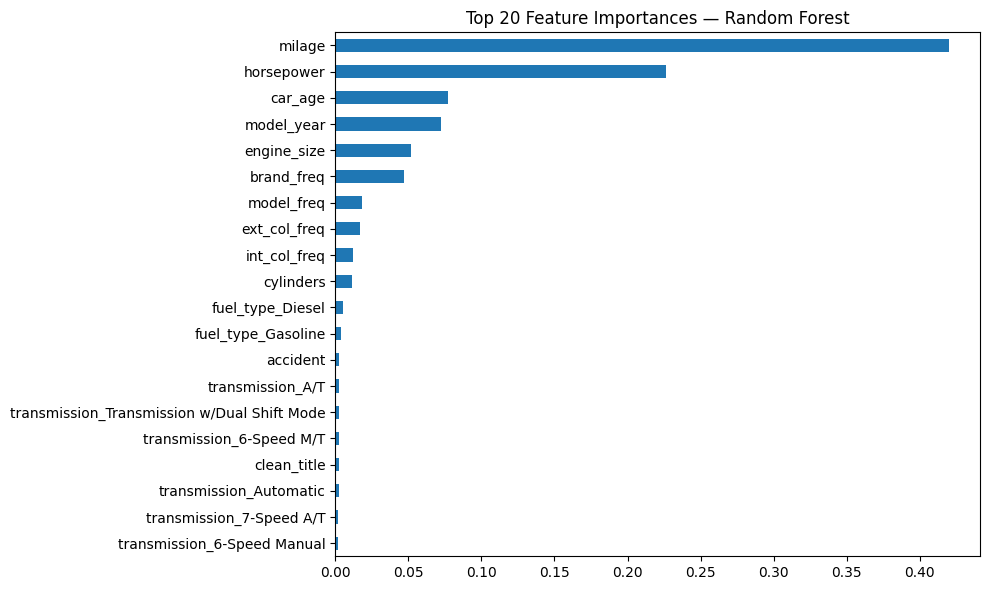

In [21]:
importances = pd.Series(rf.feature_importances_, index=x_train.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh')
plt.title('Top 20 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()